<a href="https://colab.research.google.com/github/andresmauriciolopezs5-cpu/Laboratorio-10/blob/main/Actividad_Practica_10.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### 1. Carga de Datos
Importamos el dataset Iris y seleccionamos solo las dos primeras características (longitud y ancho del sépalo).

In [1]:
from sklearn.datasets import load_iris
import pandas as pd

# Cargar el dataset Iris
iris = load_iris()
X = iris.data[:, :2]  # Usar solo las dos primeras características (longitud y ancho del sépalo)
y = iris.target

# Opcional: Convertir a DataFrame para mejor visualización de los datos originales
df = pd.DataFrame(X, columns=iris.feature_names[:2])
df['species'] = iris.target_names[y]

print("Primeras 5 filas del dataset con las dos características:")
print(df.head())

Primeras 5 filas del dataset con las dos características:
   sepal length (cm)  sepal width (cm) species
0                5.1               3.5  setosa
1                4.9               3.0  setosa
2                4.7               3.2  setosa
3                4.6               3.1  setosa
4                5.0               3.6  setosa


### 2. Preprocesamiento
Dividimos los datos en conjuntos de entrenamiento y prueba.

In [2]:
from sklearn.model_selection import train_test_split

# Dividir los datos en entrenamiento (70%) y prueba (30%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

print(f"Tamaño del conjunto de entrenamiento: {len(X_train)}")
print(f"Tamaño del conjunto de prueba: {len(X_test)}")

Tamaño del conjunto de entrenamiento: 105
Tamaño del conjunto de prueba: 45


### 3. Modelado
Creamos y entrenamos un modelo de Regresión Logística.

In [3]:
from sklearn.linear_model import LogisticRegression

# Crear una instancia del modelo de Regresión Logística
model = LogisticRegression(random_state=42, solver='liblinear') # Usamos 'liblinear' para datasets pequeños y multiclase

# Entrenar el modelo con los datos de entrenamiento
model.fit(X_train, y_train)

print("Modelo de Regresión Logística entrenado exitosamente.")

Modelo de Regresión Logística entrenado exitosamente.


### 4. Evaluación
Realizamos predicciones sobre el conjunto de prueba y calculamos la precisión (accuracy).

In [4]:
from sklearn.metrics import accuracy_score

# Realizar predicciones en el conjunto de prueba
y_pred = model.predict(X_test)

# Calcular la precisión del modelo
accuracy = accuracy_score(y_test, y_pred)

print(f"Precisión del modelo de Regresión Logística en el conjunto de prueba: {accuracy:.4f}")

Precisión del modelo de Regresión Logística en el conjunto de prueba: 0.7778


### 5. Visualización
Generamos un gráfico de dispersión para comparar las especies reales y las predicciones.

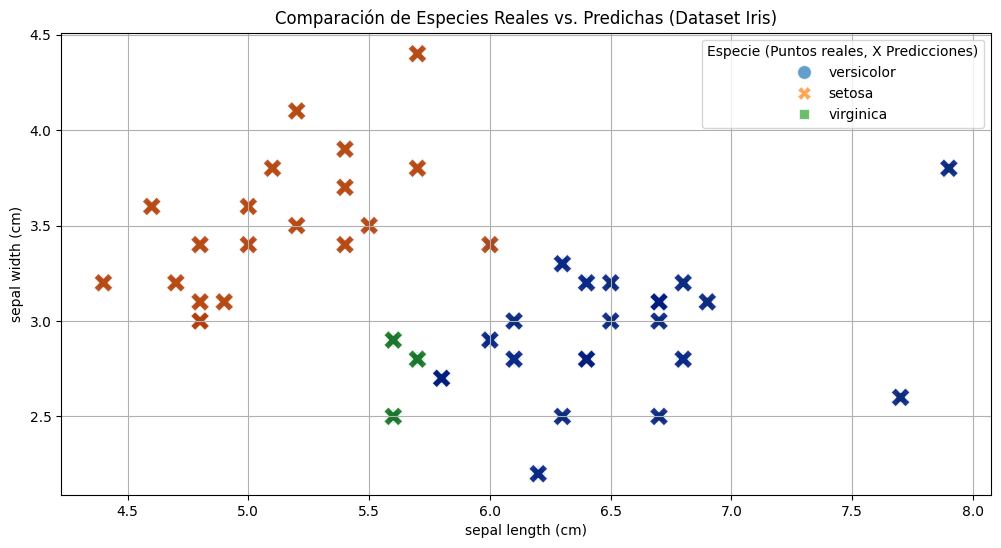

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

# Crear un DataFrame para la visualización
plot_df = pd.DataFrame(X_test, columns=iris.feature_names[:2])
plot_df['Actual Species'] = iris.target_names[y_test]
plot_df['Predicted Species'] = iris.target_names[y_pred]

plt.figure(figsize=(12, 6))

# Gráfico de dispersión para las especies reales (puntos normales)
sns.scatterplot(
    data=plot_df,
    x=iris.feature_names[0],
    y=iris.feature_names[1],
    hue='Actual Species',
    style='Actual Species', # Usa diferentes estilos para cada especie real
    s=100, # Tamaño de los puntos
    alpha=0.7 # Transparencia
)

# Gráfico de dispersión para las predicciones (marcadores 'X')
sns.scatterplot(
    data=plot_df,
    x=iris.feature_names[0],
    y=iris.feature_names[1],
    hue='Predicted Species',
    markers={'setosa': 'X', 'versicolor': 'X', 'virginica': 'X'}, # Todos los marcadores 'X'
    style='Predicted Species', # Usa diferentes estilos para cada especie predicha
    s=200, # Tamaño de los marcadores 'X'
    marker='X',
    palette='dark', # Una paleta diferente para distinguir
    legend=False, # No duplicar la leyenda de especies si ya está en 'Actual Species'
    alpha=0.9
)

plt.title('Comparación de Especies Reales vs. Predichas (Dataset Iris)')
plt.xlabel(iris.feature_names[0])
plt.ylabel(iris.feature_names[1])
plt.legend(title='Especie (Puntos reales, X Predicciones)')
plt.grid(True)
plt.show()